In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
titanic_test = pd.read_csv("C:/Users/Home/Desktop/Projects/Titanic Survivals Analysis/data/test.csv")
titanic_train = pd.read_csv("C:/Users/Home/Desktop/Projects/Titanic Survivals Analysis/data/train.csv")
titanic_gen_sub = pd.read_csv("C:/Users/Home/Desktop/Projects/Titanic Survivals Analysis/data/gender_submission.csv")

## <b> <center> EXPLORATORY DATA ANALYSIS </center> </b>

In [3]:
titanic_train.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
506,507,1,2,"Quick, Mrs. Frederick Charles (Jane Richards)",female,33.0,0,2,26360,26.0000,NaN,S
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
565,566,0,3,"Davies, Mr. Alfred J",male,24.0,2,0,A/4 48871,24.1500,NaN,S
602,603,0,1,"Harrington, Mr. Charles H",male,NaN,0,0,113796,42.4000,NaN,S
505,506,0,1,"Penasco y Castellana, Mr. Victor de Satode",male,18.0,1,0,PC 17758,108.9000,C65,C
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S
278,279,0,3,"Rice, Master. Eric",male,7.0,4,1,382652,29.1250,NaN,Q
385,386,0,2,"Davies, Mr. Charles Henry",male,18.0,0,0,S.O.C. 14879,73.5000,NaN,S
753,754,0,3,"Jonkoff, Mr. Lalio",male,23.0,0,0,349204,7.8958,NaN,S
234,235,0,2,"Leyson, Mr. Robert William Norman",male,24.0,0,0,C.A. 29566,10.5000,NaN,S


In [4]:
titanic_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
titanic_train.shape

(891, 12)

In [6]:
titanic_train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
titanic_train.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
titanic_train.describe(include = 'all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [9]:
titanic_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
titanic_train.duplicated().sum()

np.int64(0)

In [11]:
titanic_train.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


## <b><center>Exploratory Data Analysis</b>

In [12]:
titanic_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [13]:
df = titanic_train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [15]:
df.shape

(891, 8)

In [16]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\1419413682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Survived'], color='skyblue', palette=['lightblue', 'salmon'])


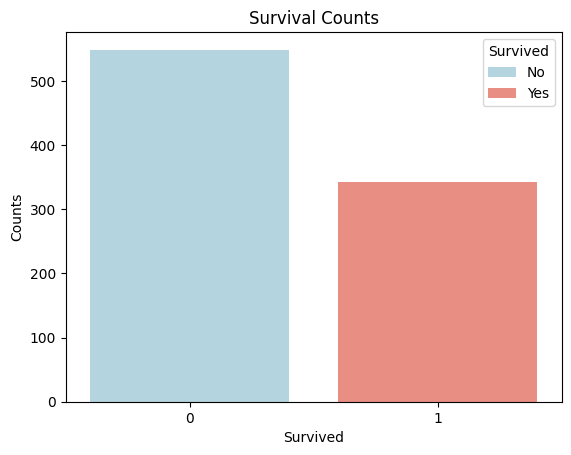

In [17]:
plt.figsize = (12, 5)

sns.countplot(x = df['Survived'], color='skyblue', palette=['lightblue', 'salmon'])
plt.title('Survival Counts')
plt.xlabel("Survived")
plt.ylabel("Counts")

plt.legend(title = 'Survived', labels = ['No', 'Yes'])

plt.show()

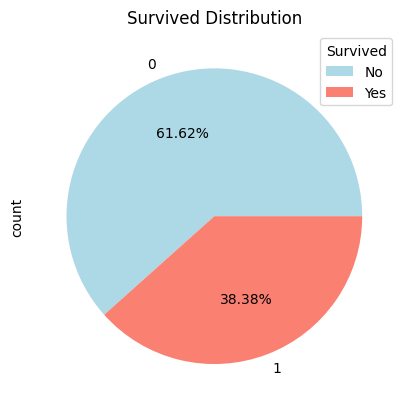

In [18]:
plt.figsize = (12, 5)

df['Survived'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon'])

plt.title("Survived Distribution")
plt.legend(title = 'Survived', labels = ['No', 'Yes'])

plt.show()

In [19]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\122211628.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Pclass'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])


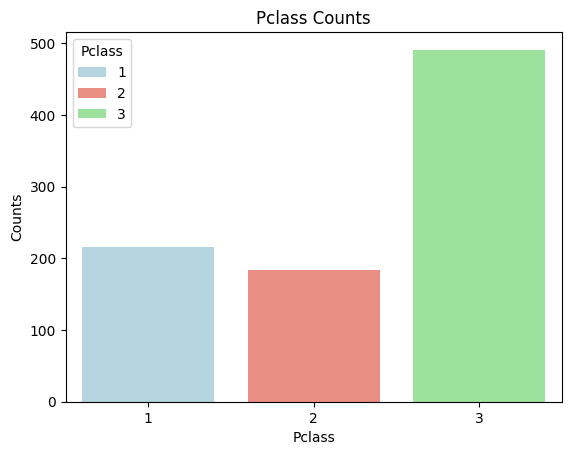

In [20]:
plt.figsize = (12, 5)

sns.countplot(x = df['Pclass'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])
plt.title('Pclass Counts')
plt.xlabel("Pclass")
plt.ylabel("Counts")

plt.legend(title = 'Pclass', labels = ['1', '2', '3'])

plt.show()

In [21]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

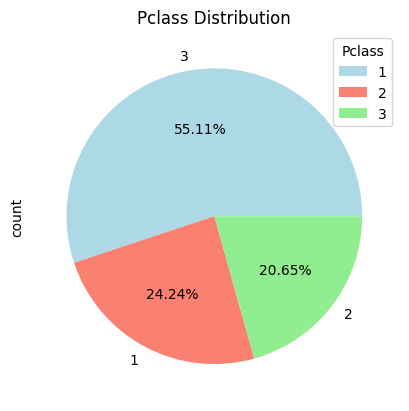

In [22]:
plt.figsize = (12, 5)

df['Pclass'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen'])

plt.title("Pclass Distribution")
plt.legend(title = 'Pclass', labels = ['1', '2', '3'])

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\2357880717.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Sex'], color='skyblue', palette=['lightblue', 'salmon'])


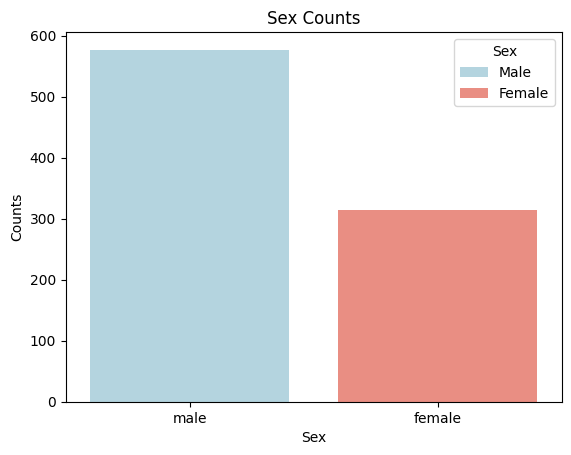

In [23]:
plt.figsize = (12, 5)

sns.countplot(x = df['Sex'], color='skyblue', palette=['lightblue', 'salmon'])
plt.title('Sex Counts')
plt.xlabel("Sex")
plt.ylabel("Counts")

plt.legend(title = 'Sex', labels = ['Male', 'Female'])

plt.show()

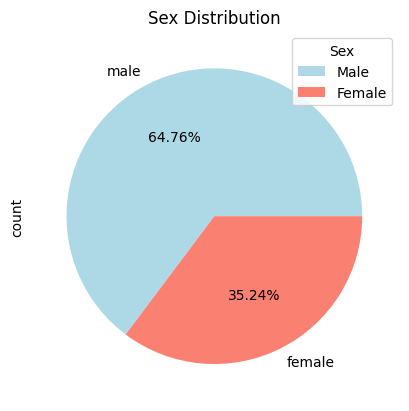

In [24]:
plt.figsize = (12, 5)

df['Sex'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon'])

plt.title("Sex Distribution")
plt.legend(title = 'Sex', labels = ['Male', 'Female'])

plt.show()

In [25]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\3655727618.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['SibSp'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightcyan', 'lightseagreen'])
C:\Users\Home\AppData\Local\Temp\ipykernel_34836\3655727618.py:3: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.countplot(x = df['SibSp'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightcyan', 'lightseagreen'])


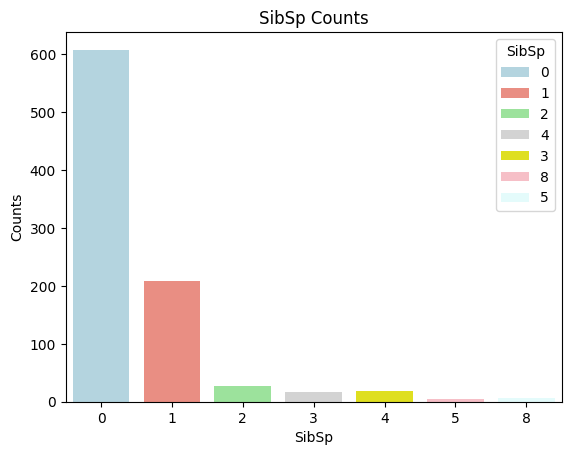

In [26]:
plt.figsize = (12, 5)

sns.countplot(x = df['SibSp'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightcyan', 'lightseagreen'])
plt.title('SibSp Counts')
plt.xlabel("SibSp")
plt.ylabel("Counts")

plt.legend(title = 'SibSp', labels = ['0', '1', '2', '4', '3', '8', '5'])

plt.show()

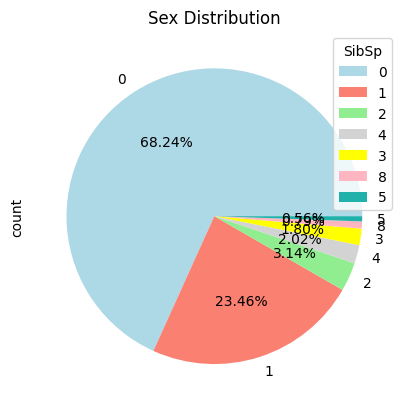

In [27]:
plt.figsize = (12, 5)

df['SibSp'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])

plt.title("Sex Distribution")
plt.legend(title = 'SibSp', labels = ['0', '1', '2', '4', '3', '8', '5'])

plt.show()

In [28]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\2915405946.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Parch'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])


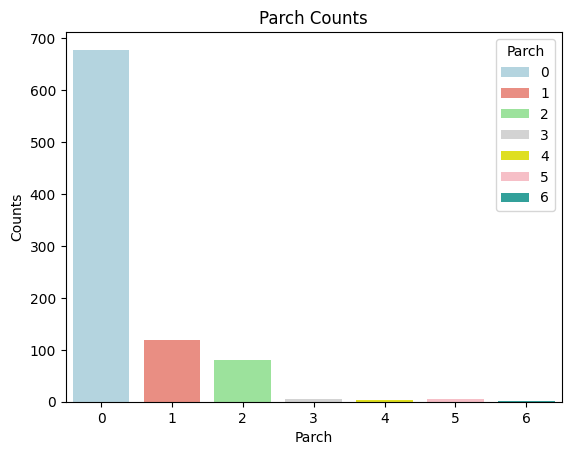

In [29]:
plt.figsize = (12, 5)

sns.countplot(x = df['Parch'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])
plt.title('Parch Counts')
plt.xlabel("Parch")
plt.ylabel("Counts")

plt.legend(title = 'Parch', labels = ['0', '1', '2', '3', '4', '5', '6'])

plt.show()

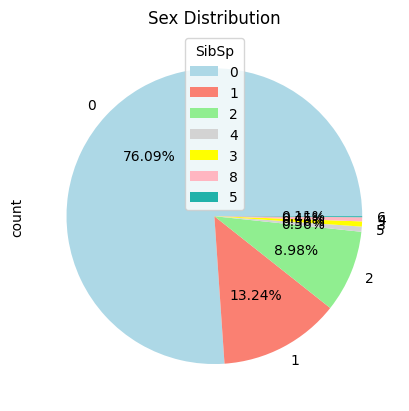

In [30]:
plt.figsize = (12, 5)

df['Parch'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])

plt.title("Sex Distribution")
plt.legend(title = 'SibSp', labels = ['0', '1', '2', '4', '3', '8', '5'])

plt.show()

In [31]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\3126860859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df['Embarked'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])


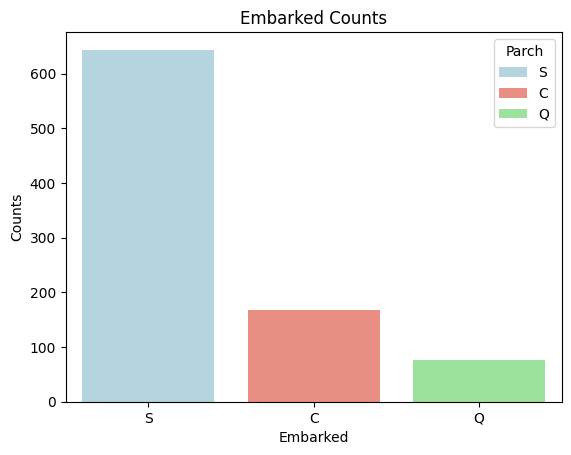

In [32]:
plt.figsize = (12, 5)

sns.countplot(x = df['Embarked'], color='skyblue', palette=['lightblue', 'salmon', 'lightgreen'])
plt.title('Embarked Counts')
plt.xlabel("Embarked")
plt.ylabel("Counts")

plt.legend(title = 'Parch', labels = ['S', 'C', 'Q'])

plt.show()

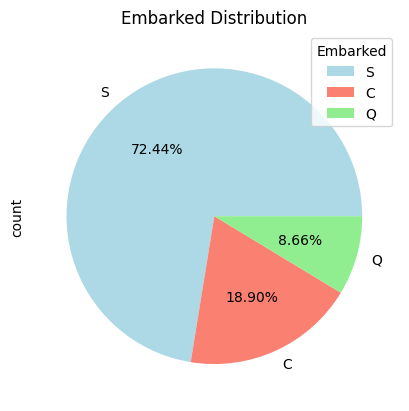

In [33]:
plt.figsize = (12, 5)

df['Embarked'].value_counts().plot(kind = 'pie', autopct = "%.2f%%", colors = ['lightblue', 'salmon', 'lightgreen', 'lightgray', 'yellow', 'lightpink', 'lightseagreen'])

plt.title("Embarked Distribution")
plt.legend(title = 'Embarked', labels = ['S', 'C', 'Q'])

plt.show()

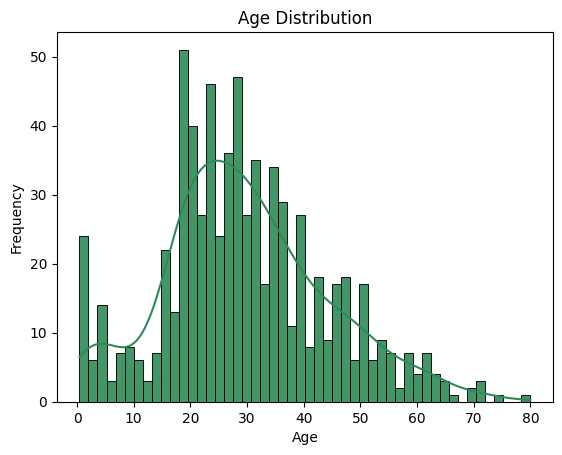

In [34]:
sns.histplot(x = df['Age'], kde = True, color = 'seagreen', bins = 50,  edgecolor = 'black', alpha = 0.9)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

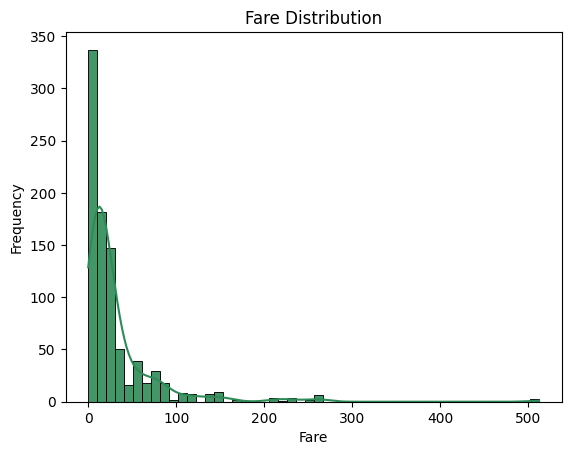

In [35]:
sns.histplot(x = df['Fare'], kde = True, color = 'seagreen', bins = 50,  edgecolor = 'black', alpha = 0.9)

plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.title("Fare Distribution")

plt.show()

In [36]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


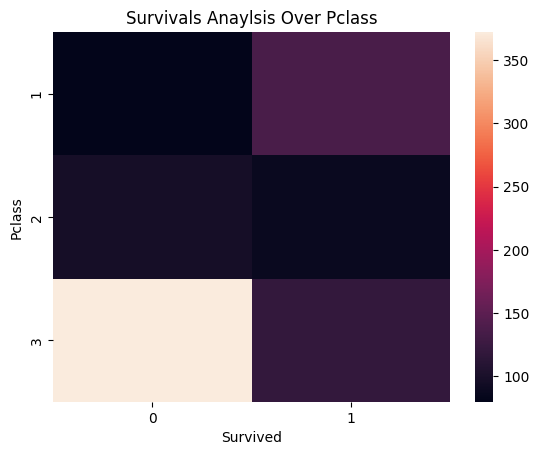

In [84]:
sns.heatmap(pd.crosstab(df['Pclass'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("Pclass")
plt.title("Survivals Anaylsis Over Pclass")

plt.show()

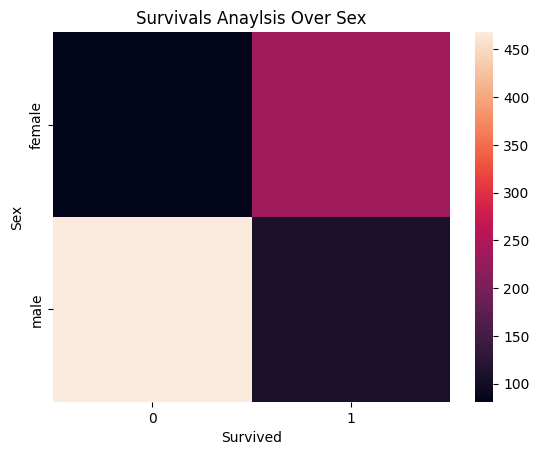

In [85]:
sns.heatmap(pd.crosstab(df['Sex'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("Sex")
plt.title("Survivals Anaylsis Over Sex")

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\4084794426.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Age'], hist = False, color = 'lightgreen')
C:\Users\Home\AppData\Local\Temp\ipykernel_34836\4084794426.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  s

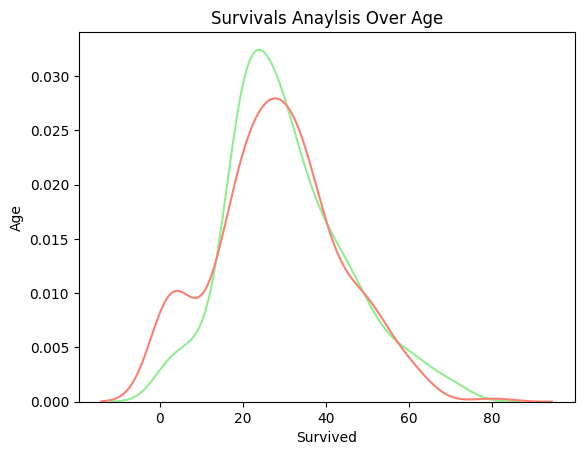

In [86]:
sns.distplot(df[df['Survived']==0]['Age'], hist = False, color = 'lightgreen')
sns.distplot(df[df['Survived']==1]['Age'], hist = False, color = 'salmon')

plt.xlabel("Survived")
plt.ylabel("Age")
plt.title("Survivals Anaylsis Over Age")

plt.show()

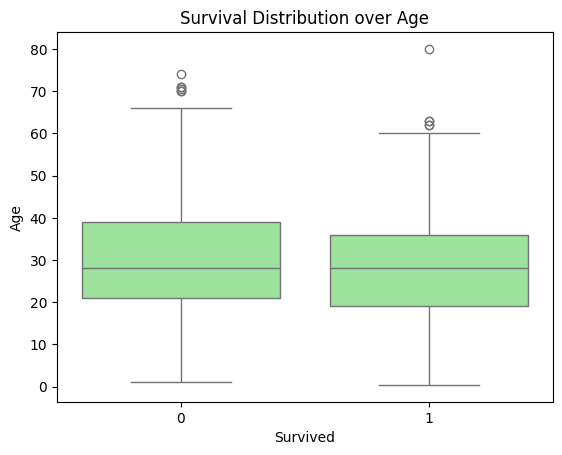

In [81]:
sns.boxplot(x = df['Survived'], y = df['Age'], data = df, color = 'lightgreen')

plt.xlabel("Survived")
plt.ylabel("Age")
plt.title("Survival Distribution over Age")

plt.show()

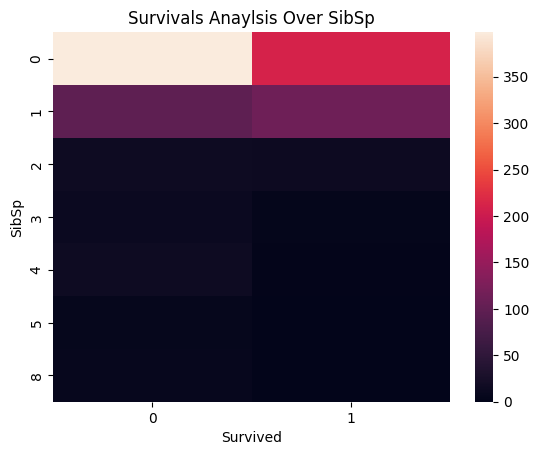

In [87]:
sns.heatmap(pd.crosstab(df['SibSp'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("SibSp")
plt.title("Survivals Anaylsis Over SibSp")

plt.show()

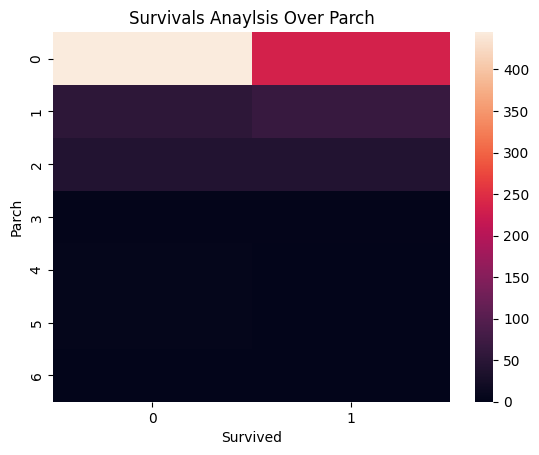

In [88]:
sns.heatmap(pd.crosstab(df['Parch'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("Parch")
plt.title("Survivals Anaylsis Over Parch")

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\1203803857.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Survived']==0]['Fare'], hist = False, color = 'lightgreen')
C:\Users\Home\AppData\Local\Temp\ipykernel_34836\1203803857.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  

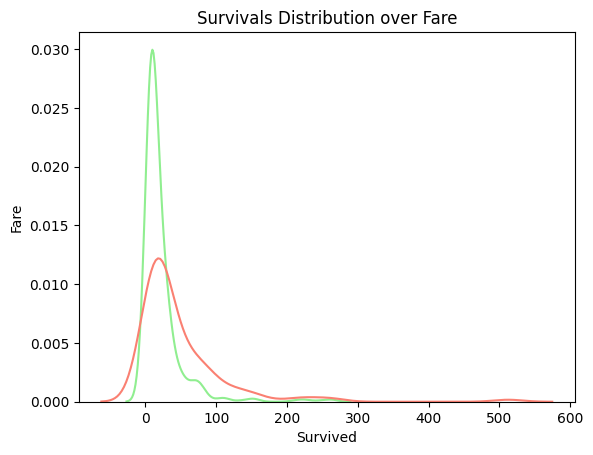

In [82]:
sns.distplot(df[df['Survived']==0]['Fare'], hist = False, color = 'lightgreen')
sns.distplot(df[df['Survived']==1]['Fare'], hist = False, color = 'salmon')

plt.xlabel("Survived")
plt.ylabel("Fare")
plt.title("Survivals Distribution over Fare")

plt.show()

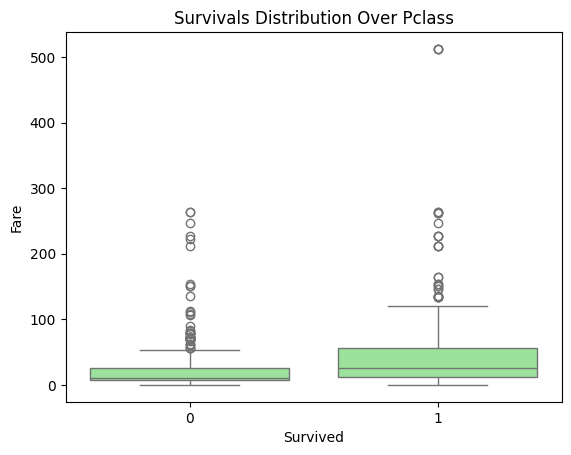

In [89]:
sns.boxplot(x = df['Survived'], y = df['Fare'], data = df, color = 'lightgreen')

plt.xlabel("Survived")
plt.ylabel("Fare")
plt.title("Survivals Distribution Over Pclass")

plt.show()

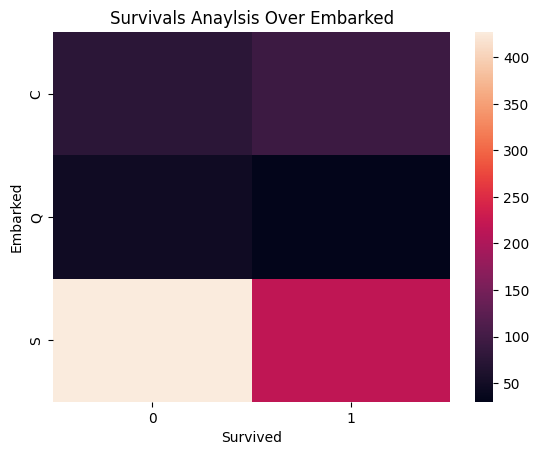

In [90]:
sns.heatmap(pd.crosstab(df['Embarked'], df['Survived']))

plt.xlabel("Survived")
plt.ylabel("Embarked")
plt.title("Survivals Anaylsis Over Embarked")

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\4236982072.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Pclass']==1]['Age'], hist = False)
C:\Users\Home\AppData\Local\Temp\ipykernel_34836\4236982072.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Pclas

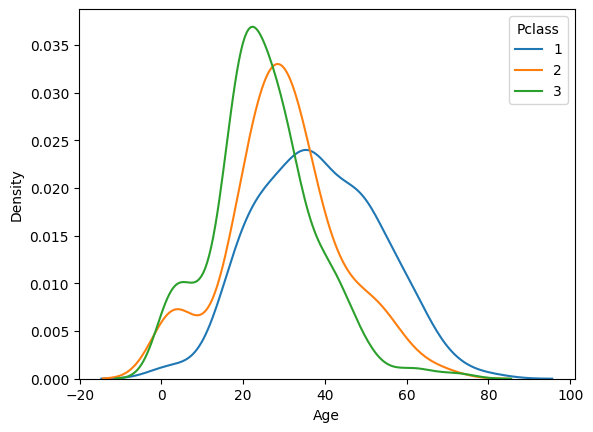

In [99]:
sns.distplot(df[df['Pclass']==1]['Age'], hist = False)
sns.distplot(df[df['Pclass']==2]['Age'], hist = False)
sns.distplot(df[df['Pclass']==3]['Age'], hist = False)

plt.legend(title = "Pclass", labels = ['1', '2', '3'])

plt.show()

C:\Users\Home\AppData\Local\Temp\ipykernel_34836\1509461532.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Pclass'] == 1]['Fare'], hist = False)
C:\Users\Home\AppData\Local\Temp\ipykernel_34836\1509461532.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['Pc

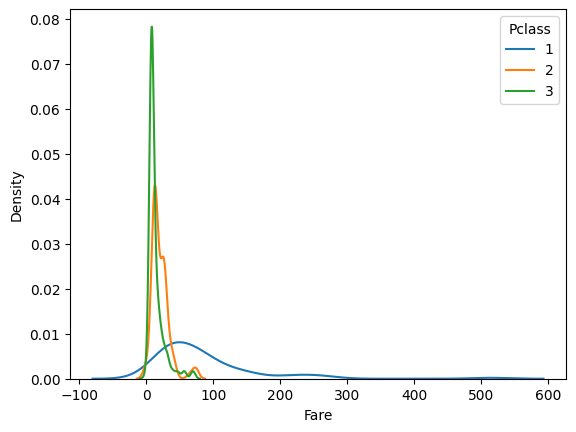

In [101]:
sns.distplot(df[df['Pclass'] == 1]['Fare'], hist = False)
sns.distplot(df[df['Pclass'] == 2]['Fare'], hist = False)
sns.distplot(df[df['Pclass'] == 3]['Fare'], hist = False)

plt.legend(title = "Pclass", labels = ['1', '2', '3'])

plt.show()

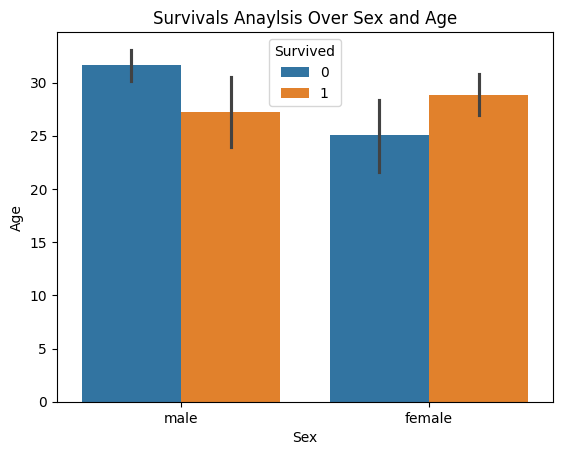

In [ ]:
sns.barplot(x = df['Sex'], y = df['Age'], hue = df['Survived'], data = df)

plt.xlabel("Sex")
plt.ylabel("Age")
plt.title("Survivals Distribution Over Sex and Age")

plt.show()

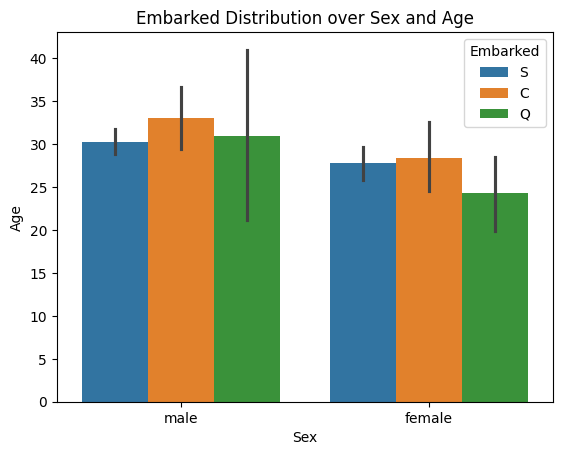

In [110]:
sns.barplot(x = df['Sex'], y = df['Age'], hue = df['Embarked'], data = df)

plt.xlabel("Sex")
plt.ylabel("Age")
plt.title("Embarked Distribution over Sex and Age")

plt.show()